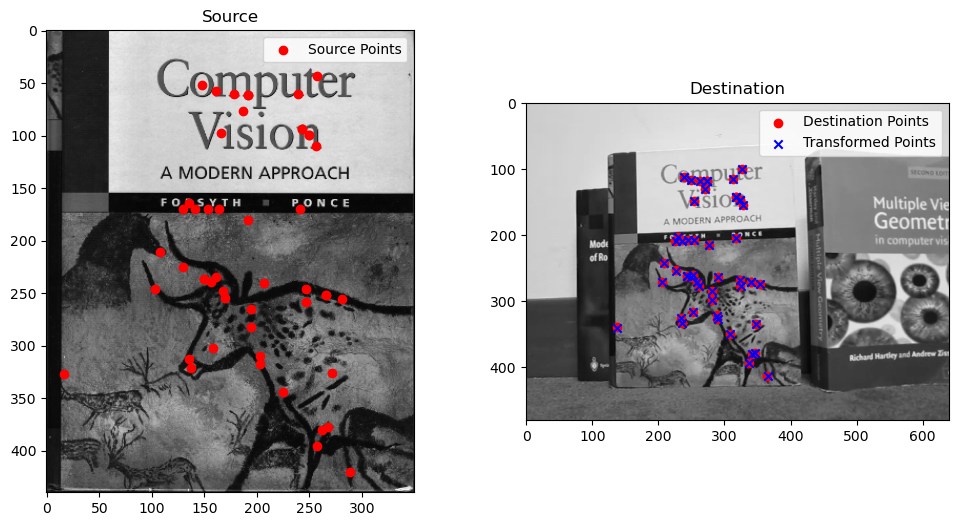

Homography Matrix:
 [[ 7.73175741e-01  2.75722138e-03  1.19569964e+02]
 [-5.11103701e-02  7.78602149e-01  7.74981421e+01]
 [-9.11956235e-05 -7.43420663e-05  1.00000000e+00]]
Transformed Points:
 [[227.07919957 253.49343744]
 [260.68454576 276.72266347]
 [243.53816957 262.36157602]
 [274.05853919 117.58582059]
 [208.9055182  242.53780383]
 [248.76128373 263.86439567]
 [322.81981891 146.27102525]
 [263.30023502 118.01364543]
 [258.81751033 271.36912293]
 [322.81981891 146.27102525]
 [274.05853919 117.58582059]
 [243.53816957 262.36157602]
 [337.07268717 393.04492694]
 [340.15219636 271.416701  ]
 [365.19804085 413.46822669]
 [347.52595352 333.73732756]
 [234.91743875 332.54663548]
 [276.91675869 214.46827435]
 [244.96993298 207.61389454]
 [233.72590145 325.55552503]
 [317.13054994 142.14048102]
 [328.69460832 154.94563802]
 [238.43731456 112.2414384 ]
 [340.15219636 271.416701  ]
 [289.33701719 321.76733913]
 [327.17723955 100.22623368]
 [136.87540508 339.87313594]
 [317.13054994 142.140

In [5]:
import os
import cv2
import numpy as np
from matplotlib import pyplot as plt

cap = cv2.VideoCapture(r"book.mp4")
ret, frame = cap.read()
cap.release()

video_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
book_image = cv2.imread("cv_cover.jpg", cv2.IMREAD_GRAYSCALE)

# Detect keypoints and compute descriptors using SIFT
sift = cv2.SIFT_create()
keypoints1, descriptors1 = sift.detectAndCompute(book_image, None)
keypoints2, descriptors2 = sift.detectAndCompute(video_frame, None)

# Match descriptors using BFMatcher with KNN
bf = cv2.BFMatcher()
matches = bf.knnMatch(descriptors1, descriptors2, k=2)

# Lowe's ratio test
good_matches = []
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)
good_matches = sorted(good_matches, key=lambda x: x.distance)[:50]

output_image = cv2.drawMatches(book_image, keypoints1, video_frame, keypoints2,
    good_matches, None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

def get_correspondences(frame1, book_img, num_correspondences=50):
    sift = cv2.SIFT_create()
    kp1, des1 = sift.detectAndCompute(book_img, None)
    kp2, des2 = sift.detectAndCompute(frame1, None)
    bf = cv2.BFMatcher()
    matches = bf.knnMatch(des1, des2, k=2)

    good_matches = []
    for m, n in matches:
        if m.distance < 0.25 * n.distance:
            good_matches.append(m)

    good_matches = good_matches[:num_correspondences]
    pts1 = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    pts2 = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)
   
    return pts1, pts2

# Compute homography matrix from point correspondences
def compute_homography(pts1, pts2):
    A = []
    for i in range(len(pts1)):
        x, y = pts1[i][0], pts1[i][1]
        u, v = pts2[i][0], pts2[i][1]
        A.append([-x, -y, -1, 0, 0, 0, u*x, u*y, u])
        A.append([0, 0, 0, -x, -y, -1, v*x, v*y, v])

    A = np.asarray(A)
    U, S, Vh = np.linalg.svd(A)
    H = Vh[-1, :].reshape(3, 3)
    H /= H[2, 2]
    return H

# Map points using homography matrix
def map_points_with_homography(H, points):
    points_homogeneous = np.hstack((points, np.ones((len(points), 1))))
    mapped_points_homogeneous = np.dot(H, points_homogeneous.T)
    # Normalize homogeneous coordinates
    mapped_points = mapped_points_homogeneous[:2, :] / mapped_points_homogeneous[2, :].reshape(1, -1)
    return mapped_points.T

# RANSAC finding the best homography using inliers
def RANSAC(pts1, pts2, num_iterations=1000, min_set_size=4, inlier_threshold=.5, min_inliers=45):
    best_H = None
    max_inliers = 0
    num_correspondences = len(pts1)
    np.random.seed(42)
    for i in range(num_iterations):
        random_indices = np.random.choice(num_correspondences, size=min_set_size, replace=False)
        sampled_pts1 = pts1[random_indices]
        sampled_pts2 = pts2[random_indices]

        initial_H = compute_homography(sampled_pts1, sampled_pts2)
        transformed_points = map_points_with_homography(initial_H, pts1)

        errors = np.sqrt(np.sum((transformed_points - pts2)**2, axis=1))
        inliers = np.sum(errors < inlier_threshold)

        if inliers > max_inliers:
            max_inliers = inliers
            best_H = initial_H

        if max_inliers > min_inliers:
            break

    return best_H

def verify_homography(H, src_points, dst_points):
    # Convert src_points to homogeneous coordinates
    src_points_h = np.hstack((src_points, np.ones((src_points.shape[0], 1))))
    dst_points_h = (H @ src_points_h.T).T  # Nx3  # Transform the points using H
    dst_points_transformed = dst_points_h[:, :2] / dst_points_h[:, 2:] # Normalize to get non-homogeneous coordinates
    return dst_points_transformed

def visualize_homography(src_img, dst_img, src_points, dst_points, transformed_points):
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(src_img, cmap='gray')
    plt.scatter(src_points[:, 0], src_points[:, 1], color='r', label='Source Points')
    plt.title("Source")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.imshow(dst_img, cmap='gray')
    plt.scatter(dst_points[:, 0], dst_points[:, 1], color='r', label='Destination Points')
    plt.scatter(transformed_points[:, 0], transformed_points[:, 1], color='b', marker='x', label='Transformed Points')
    plt.title("Destination")
    plt.legend()

    plt.show()

def get_points_from_matches(good_matches, keypoints1, keypoints2):
    src_points = []
    dst_points = []

    for match in good_matches:
        src_idx = match.queryIdx
        dst_idx = match.trainIdx
        src_points.append(keypoints1[src_idx].pt)
        dst_points.append(keypoints2[dst_idx].pt)

    return np.array(src_points), np.array(dst_points)

best_matches = sorted(good_matches, key=lambda x: x.distance)[:50]
src_pts, dst_pts = get_points_from_matches(good_matches, keypoints1, keypoints2)
H = compute_homography(src_pts, dst_pts)
transformed_pts = verify_homography(H, src_pts, dst_pts)
visualize_homography(book_image, video_frame, src_pts, dst_pts, transformed_pts)
print("Homography Matrix:\n", H)
print("Transformed Points:\n", transformed_pts)

def map_book_corners(H, book_image):
    h, w = book_image.shape[:2]

    # Define the four corners of the book
    corners = np.array([
        [0, 0],      # Top-L
        [w, 0],      # Top-R
        [w, h],      # Bottom-R
        [0, h]       # Bottom-L
    ])

    # Convert to homogeneous coordinates (x, y, 1)
    corners_homogeneous = np.hstack((corners, np.ones((4, 1))))  # Shape: (4, 3)
    # Map the corners using homography matrix
    mapped_corners_homogeneous = (H @ corners_homogeneous.T).T  # Shape: (4, 3)
    # Convert back to Cartesian coordinates
    mapped_corners = mapped_corners_homogeneous[:, :2] / mapped_corners_homogeneous[:, 2:]

    return mapped_corners

mapped_corners = map_book_corners(H, book_image)
def visualize_book_corners(video_frame, mapped_corners):
    frame_with_corners = video_frame.copy()

    for corner in mapped_corners:
        x, y = int(corner[0]), int(corner[1])
        cv2.circle(frame_with_corners, (x, y), 8, (0, 0, 255), -1)

    plt.figure(figsize=(8, 8))
    plt.imshow(cv2.cvtColor(frame_with_corners, cv2.COLOR_BGR2RGB))
    plt.title("Book Corners")
    plt.axis("off")
    plt.show()

def detect_black_bars(frame, threshold=10):

    if len(frame.shape) == 3:
        gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    else:
        gray_frame = frame

    height, width = gray_frame.shape
    y_start, y_end = 0, height

    for y in range(height):
        row = gray_frame[y, :]
        if np.mean(row) > threshold:
            y_start = y
            break

    for y in range(height - 1, -1, -1):
        row = gray_frame[y, :]
        if np.mean(row) > threshold:
            y_end = y + 1
            break

    return y_start, y_end

def crop_ar_video_frame(video_frame, book_corners):
    # Calculate the book region from mapped corners
    book_width = int(np.abs(book_corners[1][0] - book_corners[0][0]))
    book_height = int(np.abs(book_corners[3][1] - book_corners[0][1]))

    # Ensure positive and reasonable dimensions
    book_width = max(book_width, 1)
    book_height = max(book_height, 1)
    book_aspect_ratio = book_width / book_height

    y_start, y_end = detect_black_bars(video_frame)
    cropped_frame = video_frame[y_start:y_end, :, :] if len(video_frame.shape) == 3 else video_frame[y_start:y_end, :]

    # Get dimensions of the cropped frame
    crop_height, crop_width = cropped_frame.shape[:2]
    crop_aspect_ratio = crop_width / crop_height

    # Further crop to match the book's aspect ratio
    if crop_aspect_ratio > book_aspect_ratio:
        target_width = int(crop_height * book_aspect_ratio)
        x_start = (crop_width - target_width) // 2
        x_end = x_start + target_width
        y_start, y_end = 0, crop_height
    else:
        target_height = int(crop_width / book_aspect_ratio)
        y_start = (crop_height - target_height) // 2
        y_end = y_start + target_height
        x_start, x_end = 0, crop_width

    x_start = max(0, x_start)
    x_end = min(crop_width, x_end)
    y_start = max(0, y_start)
    y_end = min(crop_height, y_end)

    # Crop to match the book's aspect ratio
    final_cropped_frame = cropped_frame[y_start:y_end, x_start:x_end]

    # Resize the cropped frame to match the book region
    resized_frame = cv2.resize(final_cropped_frame, (book_width, book_height), interpolation=cv2.INTER_AREA)

    return resized_frame

# Overlay the frames of the book and AR video
def overlay_frames(frame1, frame2, H, book_corners):
    book_coordinates_video = map_points_with_homography(H, book_corners)

    mask = np.zeros_like(frame1, dtype=np.uint8)
    cv2.fillPoly(mask, [np.int32(book_coordinates_video)], (255, 255, 255))

    inverted_mask = cv2.bitwise_not(mask)
    frame1_blacked = cv2.bitwise_and(frame1, inverted_mask)
    overlay_frame = cv2.warpPerspective(frame2, H, (frame1.shape[1], frame1.shape[0]))
    result = cv2.add(frame1_blacked, overlay_frame)

    return result

def process_video(video1_path, video2_path, book_img_path):
    
    video1 = cv2.VideoCapture(video1_path)
    video2 = cv2.VideoCapture(video2_path)
    book_img = cv2.imread(book_img_path)

    width = int(video1.get(3))
    height = int(video1.get(4))
    fourcc = cv2.VideoWriter_fourcc(*'XVID')
    
    output_path = 'Output_Video.mp4'
    output_video = cv2.VideoWriter(output_path, fourcc, 30.0, (width, height))

    book_corners = np.array([[0, 0],
                             [book_img.shape[1] - 1, 0],
                             [book_img.shape[1] - 1, (book_img.shape[0] - 1)],
                             [0, (book_img.shape[0] - 1)]],
                            dtype=np.float32)

    while True:
        ret1, frame1 = video1.read()
        ret2, frame2 = video2.read()

        if not ret1 or not ret2:
            break

        # Get correspondences for each frame
        pts_book, pts_video = get_correspondences(frame1, book_img)
        # Calculate homography matrix
        H = RANSAC(np.squeeze(pts_book), np.squeeze(pts_video))
        # Crop the video frame centered on the book
        cropped_video_frame = crop_ar_video_frame(frame2, book_corners)
        # Overlay frames and write to the output video
        result_frame = overlay_frames(frame1, cropped_video_frame, H, book_corners)
        output_video.write(result_frame)

    video1.release()
    video2.release()
    output_video.release()

    return output_path

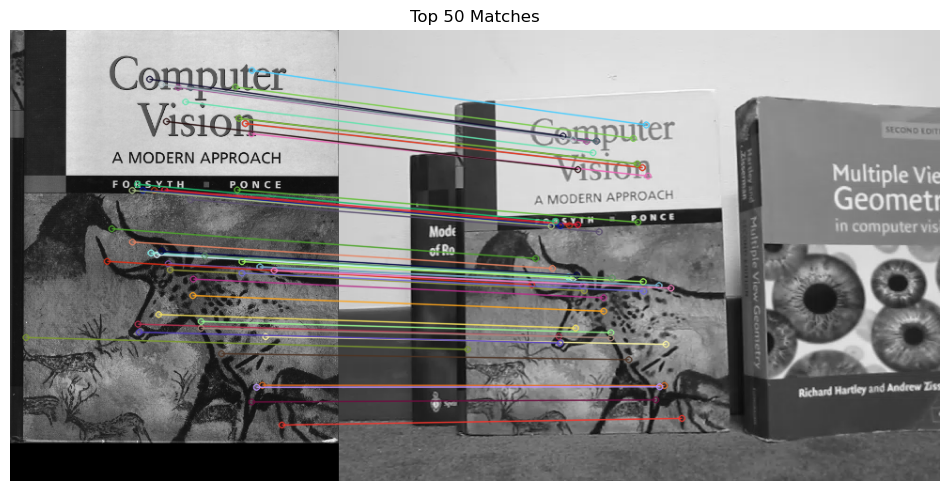

In [6]:
plt.figure(figsize=(12, 6))
plt.imshow(output_image)
plt.title("Top 50 Matches")
plt.axis("off")
plt.show()

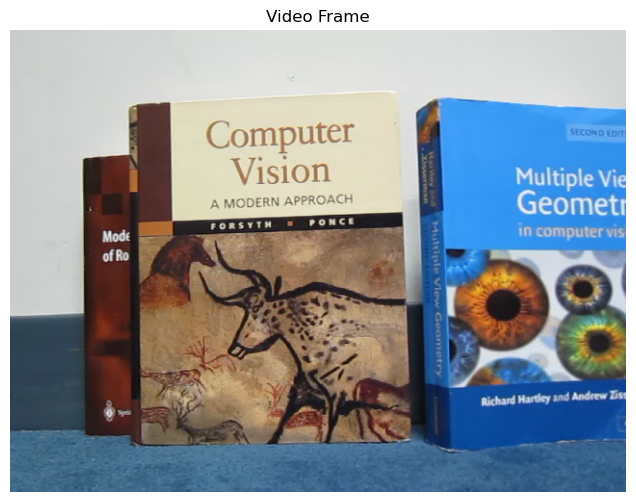

In [7]:
plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.title("Video Frame")
plt.axis("off")
plt.show()

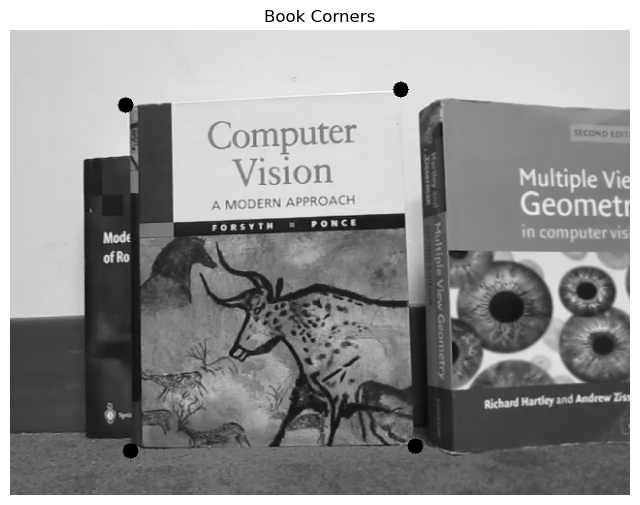

Mapped Corners:
 [[119.56996442  77.49814207]
 [403.04608733  61.57488865]
 [418.43786214 429.98387652]
 [124.86762543 434.28889884]]


In [8]:
mapped_corners = map_book_corners(H, book_image)
visualize_book_corners(video_frame, mapped_corners)
print("Mapped Corners:\n", mapped_corners)

In [5]:
video1_path = "book.mov"
video2_path = "ar_source.mov"
book_img_path = "cv_cover.jpg"
output_path = process_video(video1_path, video2_path, book_img_path)
print(f"Output saved as {output_path}")

Output saved as Output_Video.mp4
